# Interpreting Climate Representations in GPT-2 via Sparse Autoencoders
> #### **Project Goal** : Large language models such as GPT-2 encode rich semantic representations across their transformer layers, yet the internal structure of these representations remains largely opaque acting as a “Black box”. This work applies Sparse Autoencoder (SAE) analysis to investigate how climate-related concepts are encoded within the intermediate activations of GPT-2 Medium.
>
> #### Drawing on the ClimateEval dataset, which spans three distinct linguistic registers Scientific, Wikipedia, and Financial we collect token-level activations from layer 17 of GPT-2 Medium and train an SAE to decompose the dense 4096-dimensional MLP output vectors into a sparse set of interpretable features. By leveraging the multi-register structure of ClimateEval, we examine whether distinct SAE features emerge for climate concepts across different discourse contexts, and whether register-selective features can be identified that capture domain-specific language patterns such as scientific hedging, ESG financial reporting, and encyclopedic climate description.


In [1]:
!pip install -q transformers datasets accelerate einops tqdm

In [2]:
# extract_gpt2_mlp_activations.py
import os
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
SAVE_DIR     = "/content/drive/MyDrive/Colab Notebooks/SLDS_Project/token_activations"
TARGET_LAYER = 17
MODEL_NAME   = "gpt2-medium"
MAX_SENTENCES = 30_000

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Extraction Of GPT-2 Actiavtion

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.eval().to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3072, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=1024)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=4096, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=4096)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1024, out_features=50257, bias=False)
)

In [5]:
target_block = model.transformer.h[TARGET_LAYER]

In [7]:
print(f"\n{'='*80}")
print("Model Architecture Summary")
print(f"{'='*80}")

print(f"\nModel Type: {model.config.model_type}")
print(f"\nModel Name: gpt2-medium")

print(f"\nNumber of Transformer Layers: {model.config.n_layer}")

print(f"\nHidden Size (Embedding Dimension): {model.config.n_embd}")

print(f"\nNumber of Attention Heads: {model.config.n_head}")

print(f"\nHead Dimension: {model.config.n_embd // model.config.n_head}")

ffn_size = model.config.n_inner or 4 * model.config.n_embd
print(f"\nIntermediate Feed Forward Network Size: {ffn_size}")

print(f"\nMaximum Position Embeddings: {model.config.n_positions}")

print(f"\nVocabulary Size: {model.config.vocab_size}")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Parameters: {total_params:,}")

print(f"\nToken Embedding Shape: {model.transformer.wte.weight.shape}")

print(f"\nPosition Embedding Shape: {model.transformer.wpe.weight.shape}")

print(f"\nHook Point: Layer {TARGET_LAYER}, mlp.act (post-GELU)")

c_fc_weight = model.transformer.h[TARGET_LAYER].mlp.c_fc.weight

print(f"\nActivation Dimension: : {c_fc_weight.shape[0]}")

print(f"\n{'='*80}")


Model Architecture Summary

Model Type: gpt2

Model Name: gpt2-medium

Number of Transformer Layers: 24

Hidden Size (Embedding Dimension): 1024

Number of Attention Heads: 16

Head Dimension: 64

Intermediate Feed Forward Network Size: 4096

Maximum Position Embeddings: 1024

Vocabulary Size: 50257

Total Parameters: 354,823,168

Token Embedding Shape: torch.Size([50257, 1024])

Position Embedding Shape: torch.Size([1024, 1024])

Hook Point: Layer 17, mlp.act (post-GELU)

Activation Dimension: : 1024



### Example To Get Activation

In [8]:
# ── single sentence test ──────────────────────────────────────────────────────
sentence = "Global temperatures have risen significantly due to greenhouse gas emissions."

residual_store = {}
mlp_store      = {}

In [9]:
def hook_residual(module, input, output):
    residual_store["act"] = output.detach().cpu()

def hook_mlp(module, input, output):
    # output = post-GELU activation
    mlp_store["act"] = output.detach().cpu()

In [10]:
h1 = target_block.ln_2.register_forward_hook(hook_residual)
h2 = target_block.mlp.act.register_forward_hook(hook_mlp)

In [11]:
inputs = tokenizer(sentence, return_tensors="pt").to(device)
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

with torch.no_grad():
    model(**inputs)

h1.remove()
h2.remove()

In [12]:
res = residual_store["act"].squeeze(0)
mlp = mlp_store["act"].squeeze(0)

print(f"Tokens:         {tokens}")
print(f"Residual shape: {res.shape}")
print(f"MLP shape:      {mlp.shape}")
print()
print(f"{'Token':<20} {'Residual L2':>12}  {'MLP L2':>10}")
print("-" * 46)
for i, tok in enumerate(tokens):
    print(f"{tok:<20} {res[i].norm().item():>12.3f}  {mlp[i].norm().item():>10.3f}")

Tokens:         ['Global', 'Ġtemperatures', 'Ġhave', 'Ġrisen', 'Ġsignificantly', 'Ġdue', 'Ġto', 'Ġgreenhouse', 'Ġgas', 'Ġemissions', '.']
Residual shape: torch.Size([11, 1024])
MLP shape:      torch.Size([11, 4096])

Token                 Residual L2      MLP L2
----------------------------------------------
Global                      6.646       6.501
Ġtemperatures               6.948      11.768
Ġhave                       7.192      16.285
Ġrisen                      7.788      14.447
Ġsignificantly              7.298      12.302
Ġdue                        7.903      13.039
Ġto                         7.349      15.260
Ġgreenhouse                 8.056      12.786
Ġgas                        8.068      15.513
Ġemissions                  7.334      11.161
.                           5.938      12.152


### Load ClimateEval

In [13]:
ds_climate = load_dataset("murathankurfali/ClimateEval", split="train")

climate_dataset = pd.DataFrame(ds_climate, columns=['label', 'sentence'])
climate_dataset.head()

clima_text/train-data/AL-10Ks.tsv : 3000(…):   0%|          | 0.00/534k [00:00<?, ?B/s]

clima_text/train-data/AL-Wiki (train).ts(…):   0%|          | 0.00/451k [00:00<?, ?B/s]

clima_text/train-data/Wiki-Doc-Train.tsv:   0%|          | 0.00/19.4M [00:00<?, ?B/s]

clima_text/dev-data/Wiki-Doc-Dev.tsv:   0%|          | 0.00/603k [00:00<?, ?B/s]

clima_text/dev-data/Wikipedia (dev).tsv:   0%|          | 0.00/53.3k [00:00<?, ?B/s]

...

clima_text/test-data/Wikipedia (test).ts(…):   0%|          | 0.00/51.7k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/121847 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3918 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5426 [00:00<?, ? examples/s]

,label,sentence
0,0,• collection of debts from loan customers wh...
1,0,"All known, material risks and uncertainties ar..."
2,1,Although it is not possible at this time to pr...
3,0,"Ifthere is a decline in real estate values, as..."
4,0,Our expenses have exceeded ourrevenue since in...


In [14]:
climate_dataset.shape

(121847, 2)

In [15]:
climate_texts = climate_dataset["sentence"].tolist()
climate_labels = climate_dataset["label"].tolist()

In [16]:
climate_texts = climate_texts[:MAX_SENTENCES]
climate_labels = climate_labels[:MAX_SENTENCES]

### Hook setup

In [17]:
residual_pre_mlp = {}
mlp_activations  = {}

def hook_residual_pre_mlp(module, input):
    residual_pre_mlp[0] = input[0].detach().cpu()

def hook_mlp_post_gelu(module, input, output):
    mlp_activations[0] = output.detach().cpu()

hooks = []
hooks.append(target_block.ln_2.register_forward_pre_hook(hook_residual_pre_mlp))
hooks.append(target_block.mlp.act.register_forward_hook(hook_mlp_post_gelu))

print(f"Hooks registered on layer {TARGET_LAYER}")

Hooks registered on layer 17


### Collect and Store Activations Per Token

In [18]:
all_activations = []

for sent in tqdm(climate_texts):
    residual_pre_mlp.clear()
    mlp_activations.clear()

    inputs = tokenizer(
        sent,
        return_tensors="pt",
        truncation=True,
    ).to(device)

    with torch.no_grad():
        model(**inputs)

    res_tensor = residual_pre_mlp[0].squeeze(0)
    mlp_tensor = mlp_activations[0].squeeze(0)

    token_dict = {}
    for i, token_id in enumerate(inputs.input_ids[0]):
        token = tokenizer.decode(token_id)
        token_dict[i] = {
            "token":           token,
            "residual_pre_mlp": res_tensor[i].numpy(),
            "mlp_post_full":    mlp_tensor[i].numpy(),
            "sentence":         sent[:200]
        }

    all_activations.append((sent, token_dict))

# remove hooks
for h in hooks:
    h.remove()

print(f"Done! Collected activations for {len(all_activations):,} sentences")

100%|██████████| 30000/30000 [10:47<00:00, 46.30it/s]

Done! Collected activations for 30,000 sentences


In [19]:
residuals_list    = []
mlp_list          = []
tokens_list       = []
sentence_idx_list = []
position_idx_list = []
label_list        = []

for sent_idx, (sentence, pos_dict) in enumerate(all_activations):
    for pos_idx, token_info in pos_dict.items():
        residuals_list.append(token_info["residual_pre_mlp"])
        mlp_list.append(token_info["mlp_post_full"])
        tokens_list.append(token_info["token"])
        sentence_idx_list.append(sent_idx)
        position_idx_list.append(pos_idx)
        label_list.append(climate_labels[sent_idx])

residuals_tensor     = torch.tensor(np.stack(residuals_list), dtype=torch.float32)
mlp_tensor           = torch.tensor(np.stack(mlp_list),       dtype=torch.float32)
sentence_idx_tensor  = torch.tensor(sentence_idx_list,        dtype=torch.long)
position_idx_tensor  = torch.tensor(position_idx_list,        dtype=torch.long)
label_tensor         = torch.tensor(label_list,               dtype=torch.long)

print(f"residuals_tensor:  {residuals_tensor.shape}")
print(f"mlp_tensor:        {mlp_tensor.shape}")
print(f"Total tokens:      {residuals_tensor.shape[0]:,}")
print(f"Unique sentences:  {len(all_activations):,}")
print(f"Avg tokens/sent:   {residuals_tensor.shape[0]/len(all_activations):.1f}")

residuals_tensor:  torch.Size([839773, 1024])
mlp_tensor:        torch.Size([839773, 4096])
Total tokens:      839,773
Unique sentences:  30,000
Avg tokens/sent:   28.0


### Store Activation to Drive

In [20]:
os.makedirs(SAVE_DIR, exist_ok=True)

output_file = f"{SAVE_DIR}/climateeval_gpt2_layer{TARGET_LAYER}_activations.pt"

In [21]:
torch.save({
    "residuals_post_attn": residuals_tensor,
    "mlp_post_full":       mlp_tensor,
    "tokens":              tokens_list,
    "sentence_idx":        sentence_idx_tensor,
    "position_idx":        position_idx_tensor,
    "labels":              label_tensor,
    "layer":               TARGET_LAYER,
    "model":               MODEL_NAME,
}, output_file)

print(f"Saved to: {output_file}")

Saved to: /content/drive/MyDrive/Colab Notebooks/SLDS_Project/token_activations/climateeval_gpt2_layer17_activations.pt


In [22]:
print(mlp_tensor.shape)
print(mlp_tensor.device)

torch.Size([839773, 4096])
cpu


## **SAE Training**

In [23]:
#Session specific loading
#data = torch.load(f"{SAVE_DIR}/climateeval_gpt2_layer17_activations.pt")
#mlp_tensor   = data["mlp_post_full"]
#tokens_list  = data["tokens"]
#label_tensor = data["labels"]

print(f"Loaded: {mlp_tensor.shape}")

Loaded: torch.Size([839773, 4096])


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, dict_size):
        super().__init__()
        self.input_dim = input_dim
        self.dict_size = dict_size

        # encoder
        self.W_enc = nn.Parameter(torch.empty(input_dim, dict_size))
        self.b_enc = nn.Parameter(torch.zeros(dict_size))

        # decoder
        self.W_dec = nn.Parameter(torch.empty(dict_size, input_dim))
        self.b_dec = nn.Parameter(torch.zeros(input_dim))

        # initialize
        nn.init.kaiming_uniform_(self.W_enc)
        nn.init.kaiming_uniform_(self.W_dec)
        self._normalize_decoder()

    @torch.no_grad()
    def _normalize_decoder(self):
        norms = self.W_dec.norm(dim=1, keepdim=True).clamp(min=1.0)
        self.W_dec.data /= norms

    def encode(self, x):
        x_c    = x - self.b_dec
        pre    = x_c @ self.W_enc + self.b_enc
        return F.relu(pre)

    def decode(self, f):
        return f @ self.W_dec + self.b_dec

    def forward(self, x):
        f     = self.encode(x)
        x_hat = self.decode(f)
        return f, x_hat

    def loss(self, x, f, x_hat, l1_coeff):
        recon = ((x - x_hat) ** 2).sum(dim=-1).mean()
        l1    = f.abs().sum(dim=-1).mean()
        total = recon + l1_coeff * l1
        return total, recon, l1

# sanity check
INPUT_DIM = 4096
DICT_SIZE = 32768   # 8x expansion

sae_test = SparseAutoencoder(INPUT_DIM, DICT_SIZE)
dummy    = torch.randn(4, INPUT_DIM)
f, x_hat = sae_test(dummy)
print(f"SAE sanity check passed!")
print(f"input:  {dummy.shape}")
print(f"features: {f.shape}")      # (4, 32768)
print(f"reconstruction: {x_hat.shape}")  # (4, 4096)

SAE sanity check passed!
input:  torch.Size([4, 4096])
features: torch.Size([4, 32768])
reconstruction: torch.Size([4, 4096])


### Training Config

In [25]:
from torch.utils.data import DataLoader, TensorDataset

# config
INPUT_DIM  = 4096
DICT_SIZE  = 32768    # 8x expansion
L1_COEFF   = 0.4
LR         = 1e-4
BATCH_SIZE = 2048
EPOCHS     = 10
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# dataset
dataset    = TensorDataset(mlp_tensor)
loader     = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0        # 0 for Colab
)

print(f"Training samples: {len(dataset):,}")
print(f"Batches per epoch: {len(loader):,}")
print(f"Input dim: {INPUT_DIM}")
print(f"Dict size: {DICT_SIZE}")

Using device: cuda
Training samples: 839,773
Batches per epoch: 411
Input dim: 4096
Dict size: 32768


### Training Loop

In [26]:
import json
from tqdm import tqdm

# initialize
sae       = SparseAutoencoder(INPUT_DIM, DICT_SIZE).to(DEVICE)
optimizer = torch.optim.Adam(sae.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS * len(loader)
)

history = []
print(f"Training SAE on {DEVICE}...")
print(f"Total tokens: {len(dataset):,}")
print(f"Dict size: {DICT_SIZE} features")
print("-" * 60)

for epoch in range(EPOCHS):
    epoch_total = 0
    epoch_recon = 0
    epoch_l1    = 0
    mean_active = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for batch in pbar:
        x = batch[0].to(DEVICE)

        f, x_hat               = sae(x)
        loss, recon, l1        = sae.loss(x, f, x_hat, L1_COEFF)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(sae.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        # keep decoder unit norm
        sae._normalize_decoder()

        epoch_total += loss.item()
        epoch_recon += recon.item()
        epoch_l1    += l1.item()
        mean_active += (f > 0).float().sum(dim=-1).mean().item()

        pbar.set_postfix(
            loss  = f"{loss.item():.4f}",
            recon = f"{recon.item():.4f}",
            l1    = f"{l1.item():.4f}",
            active= f"{(f > 0).float().sum(dim=-1).mean().item():.1f}"
        )

    n = len(loader)
    stats = {
        "epoch":       epoch + 1,
        "loss":        epoch_total / n,
        "recon":       epoch_recon / n,
        "l1":          epoch_l1    / n,
        "mean_active": mean_active / n
    }
    history.append(stats)
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  loss={stats['loss']:.4f} | recon={stats['recon']:.4f} | "
          f"l1={stats['l1']:.4f} | avg_active_features={stats['mean_active']:.1f}")

Training SAE on cuda...
Total tokens: 839,773
Dict size: 32768 features
------------------------------------------------------------


Epoch 1/10: 100%|██████████| 411/411 [01:36<00:00,  4.28it/s, active=191.1, l1=35.5613, loss=86.9140, recon=72.6895]



Epoch 1 Summary:
  loss=115.3020 | recon=101.4563 | l1=34.6141 | avg_active_features=287.4


Epoch 2/10: 100%|██████████| 411/411 [01:36<00:00,  4.27it/s, active=236.4, l1=39.4750, loss=73.4388, recon=57.6488]



Epoch 2 Summary:
  loss=81.3433 | recon=66.3285 | l1=37.5370 | avg_active_features=208.8


...


Epoch 8 Summary:
  loss=61.0042 | recon=45.2059 | l1=39.4956 | avg_active_features=230.0


Epoch 9/10: 100%|██████████| 411/411 [01:36<00:00,  4.25it/s, active=237.9, l1=40.2353, loss=64.4273, recon=48.3332]



Epoch 9 Summary:
  loss=60.6723 | recon=44.8732 | l1=39.4978 | avg_active_features=230.0


Epoch 10/10: 100%|██████████| 411/411 [01:36<00:00,  4.26it/s, active=241.8, l1=40.8069, loss=61.1880, recon=44.8652]


Epoch 10 Summary:
  loss=60.5497 | recon=44.7475 | l1=39.5054 | avg_active_features=230.0


### Save SAE weights immediately after training

In [27]:
import os
os.makedirs(SAVE_DIR, exist_ok=True)

# save weights (~500MB for 32768 features)
torch.save(
    sae.state_dict(),
    f"{SAVE_DIR}/sae_gpt2medium_layer{TARGET_LAYER}_4096x8.pt"
)

# save config + history
config = {
    "input_dim":   INPUT_DIM,
    "dict_size":   DICT_SIZE,
    "l1_coeff":    L1_COEFF,
    "lr":          LR,
    "epochs":      EPOCHS,
    "batch_size":  BATCH_SIZE,
    "model":       "gpt2-medium",
    "layer":       TARGET_LAYER,
    "hook_point":  "mlp_post_gelu_4096",
    "n_tokens":    len(dataset),
    "history":     history
}

with open(f"{SAVE_DIR}/sae_config.json", "w") as f:
    json.dump(config, f, indent=2)

print(f"SAE weights saved!")
print(f"features: {DICT_SIZE}")
print(f"trained on: {len(dataset):,} tokens")

SAE weights saved!
features: 32768
trained on: 839,773 tokens


## Feature Interpretation

###Load SAE and compute feature activations

In [28]:
import numpy as np
from collections import defaultdict
from collections import Counter

# make sure sae is loaded (if session died reload with):
#sae = SparseAutoencoder(INPUT_DIM, DICT_SIZE).to(device)
#sae.load_state_dict(torch.load(f"{SAVE_DIR}/sae_gpt2medium_layer{TARGET_LAYER}_4096x8.pt"))
#sae.eval()

In [29]:
print("Computing feature activations...")

# running stats - don't store full matrix!
feature_sum      = torch.zeros(DICT_SIZE)
feature_sq_sum   = torch.zeros(DICT_SIZE)
feature_nonzero  = torch.zeros(DICT_SIZE)
total_tokens     = 0

# for top token analysis - store only top activations per feature
top_vals    = torch.zeros(DICT_SIZE, 20)   # top 20 values per feature
top_indices = torch.zeros(DICT_SIZE, 20, dtype=torch.long)

with torch.no_grad():
    for i in tqdm(range(0, len(mlp_tensor), 2048)):
        batch = mlp_tensor[i:i+2048].to(DEVICE)
        f, _  = sae(batch)
        f     = f.cpu()

        n = f.shape[0]
        feature_sum     += f.sum(0)
        feature_sq_sum  += (f**2).sum(0)
        feature_nonzero += (f > 0).float().sum(0)
        total_tokens    += n

        # update top activating tokens per feature
        combined_vals    = torch.cat([top_vals, f.T], dim=1)
        combined_indices = torch.cat([
            top_indices,
            torch.arange(i, i+n).unsqueeze(0).expand(DICT_SIZE, -1)
        ], dim=1)

        top_k = combined_vals.topk(20, dim=1)
        top_vals    = top_k.values
        top_indices = combined_indices.gather(1, top_k.indices)

        # free GPU memory immediately
        del f, batch
        torch.cuda.empty_cache()

# compute final stats
mean_act   = feature_sum / total_tokens
frac_active = feature_nonzero / total_tokens

print(f"Done! Processed {total_tokens:,} tokens")
print(f"Mean activation: {mean_act.mean():.4f}")
print(f"Frac active:     {frac_active.mean():.4f}")

Computing feature activations...


100%|██████████| 411/411 [05:15<00:00,  1.30it/s]

Done! Processed 839,773 tokens
Mean activation: 0.0012
Frac active:     0.0070


### Dead Feature Analysis

In [30]:
dead_thresh = 1e-4
n_dead      = (frac_active < dead_thresh).sum().item()
n_alive     = (frac_active >= dead_thresh).sum().item()

print(f"=== Dead Feature Analysis ===")
print(f"Total features:  {DICT_SIZE:,}")
print(f"Dead features:   {n_dead:,}  ({100*n_dead/DICT_SIZE:.1f}%)")
print(f"Alive features:  {n_alive:,} ({100*n_alive/DICT_SIZE:.1f}%)")

# top 20 most active features
print(f"\n=== Top 20 Most Active Features ===")
top_features = mean_act.argsort(descending=True)[:20]
for i, feat_idx in enumerate(top_features.tolist()):
    print(f"  [{i+1:2d}] Feature {feat_idx:5d} | "
          f"mean_act={mean_act[feat_idx]:.4f} | "
          f"frac_active={frac_active[feat_idx]:.4f}")

=== Dead Feature Analysis ===
Total features:  32,768
Dead features:   12,661  (38.6%)
Alive features:  20,107 (61.4%)

=== Top 20 Most Active Features ===
  [ 1] Feature 17036 | mean_act=0.1068 | frac_active=0.0470
  [ 2] Feature 10413 | mean_act=0.0902 | frac_active=0.0367
  [ 3] Feature  7515 | mean_act=0.0332 | frac_active=0.0915
  [ 4] Feature  3640 | mean_act=0.0314 | frac_active=0.0493
  [ 5] Feature 27706 | mean_act=0.0280 | frac_active=0.0315
  [ 6] Feature 24088 | mean_act=0.0280 | frac_active=0.0973
  [ 7] Feature 18808 | mean_act=0.0278 | frac_active=0.0746
  [ 8] Feature 14034 | mean_act=0.0276 | frac_active=0.0338
  [ 9] Feature 16705 | mean_act=0.0274 | frac_active=0.0508
  [10] Feature  3908 | mean_act=0.0271 | frac_active=0.0853
  [11] Feature 18897 | mean_act=0.0270 | frac_active=0.0524
  [12] Feature 31635 | mean_act=0.0269 | frac_active=0.0450
  [13] Feature 20397 | mean_act=0.0268 | frac_active=0.1045
  [14] Feature 23477 | mean_act=0.0267 | frac_active=0.0735
  [1

### Top activating tokens per feature:

In [31]:
print("=== Top Tokens Per Feature ===\n")

top_features = mean_act.argsort(descending=True)[:20].tolist()

for feat_idx in top_features:
    # get top token indices for this feature
    tok_indices = top_indices[feat_idx].tolist()
    tok_values  = top_vals[feat_idx].tolist()

    # get actual tokens and labels
    tokens      = [tokens_list[i].replace("Ġ", "").strip() for i in tok_indices]
    labels      = [label_tensor[i].item() for i in tok_indices]

    print(f"Feature {feat_idx:5d} | "
          f"mean_act={mean_act[feat_idx]:.4f} | "
          f"frac_active={frac_active[feat_idx]:.4f}")
    print(f"  Tokens: {tokens}")
    print(f"  Values: {[round(v,3) for v in tok_values]}")
    print(f"  Labels: {labels}")
    print()

=== Top Tokens Per Feature ===

Feature 17036 | mean_act=0.1068 | frac_active=0.0470
  Tokens: ['SR', 'IG', 'GL', 'by', 'by', 'by', 'by', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'SG', 'SG']
  Values: [2.999, 2.997, 2.996, 2.996, 2.996, 2.996, 2.996, 2.995, 2.995, 2.995, 2.995, 2.995, 2.995, 2.995, 2.995, 2.995, 2.995, 2.995, 2.995, 2.995]
  Labels: [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1]

Feature 10413 | mean_act=0.0902 | frac_active=0.0367
  Tokens: ['Sov', 'show', 'Blu', 'Blu', 'Ly', 'Ly', 'Ly', 'by', 'by', 'by', 'by', 'Meg', 'Meg', 'Meg', 'Meg', 'Meg', 'Meg', 'Paper', 'Thor', 'By']
  Values: [2.548, 2.548, 2.545, 2.545, 2.545, 2.545, 2.545, 2.544, 2.544, 2.544, 2.544, 2.544, 2.544, 2.544, 2.544, 2.544, 2.544, 2.544, 2.544, 2.543]
  Labels: [1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]

Feature  7515 | mean_act=0.0332 | frac_active=0.0915
  Tokens: ['companies', 'scale', 'gases', 'osphere', 'consumers', 'out', 'out', 'direction', 's'

### Register selective features

In [32]:
#Find climate features

SEARCH_RANGE = 500
alive_features = mean_act.argsort(descending=True)[20:SEARCH_RANGE].tolist()

climate_keywords = [
    "emission", "carbon", "climate", "temperature", "warming",
    "greenhouse", "fossil", "renewable", "sea", "arctic",
    "drought", "flood", "storm", "energy", "policy",
    "financial", "risk", "investment", "esg", "disclosure",
    "electricity", "species", "ecosystem", "ocean", "research",
    "evidence", "organism", "disease", "atmosphere", "glacier"
]

print("=== Finding Climate Features ===\n")

new_interesting_features = []

for feat_idx in alive_features:
    tok_indices = top_indices[feat_idx].tolist()
    tokens      = [tokens_list[i].replace("Ġ", "").strip().lower()
                   for i in tok_indices]
    matches     = [t for t in tokens
                   if any(k in t for k in climate_keywords)]

    # We keep the feature which consistently fires in climate-related words with 2+ matches
    if len(matches) >= 2:
        labels = [label_tensor[i].item() for i in tok_indices]
        new_interesting_features.append(feat_idx)
        print(f"Feature {feat_idx:5d} | frac_active={frac_active[feat_idx]:.4f}")
        print(f"  Tokens:  {tokens[:10]}")
        print(f"  Matches: {matches[:]}")
        print(f"  Labels:  {labels[:10]}")
        print()

print(f"\nFound {len(new_interesting_features)} climate features!")

=== Finding Climate Features ===

Feature  8742 | frac_active=0.0417
  Tokens:  ['climate', 'climate', 'climate', 'climate', 'climate', 'climate', 'climate', 'climate', 'climate', 'climate']
  Matches: ['climate', 'climate', 'climate', 'climate', 'climate', 'climate', 'climate', 'climate', 'climate', 'climate', 'climate', 'climate', 'climate', 'climate', 'climate', 'climate', 'climate', 'climate', 'climate', 'climate']
  Labels:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Feature  7511 | frac_active=0.0711
  Tokens:  ['species', 'species', 'species', 'species', 'species', 'species', 'species', 'a', 'species', 'species']
  Matches: ['species', 'species', 'species', 'species', 'species', 'species', 'species', 'species', 'species', 'species', 'species', 'species', 'species', 'species', 'species', 'species', 'species', 'species', 'species']
  Labels:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Feature  2593 | frac_active=0.0690
  Tokens:  ['atmosphere', 'ges', 'osphere', 'cylinder', 'osphere', 'atmosphere', ','

In [37]:
interesting_features = [
    # Climate-Selective
    15766, 8742, 6790, 25142, 511,
    # Mildly-Climate
    1041, 22296, 12933, 27521, 2470, 13676, 18345,
    # Shared
    25825, 32544, 21033, 14317, 32614, 4717,
    # Non-Climate
    23612, 7511, 28227
]

feature_names = {
    15766: "Carbon",
    8742:  "Climate",
    6790:  "Greenhouse/Emissions",
    25142: "Coral Reefs/Ecosystem",
    511:   "Solar/Atmospheric",
    1041:  "Temperature",
    22296: "Warming/Rise",
    12933: "Financial/Emissions",
    27521: "Weather Systems",
    2470:  "Scientific Evidence",
    13676: "Energy/Power",
    18345: "Emission Rates",
    25825: "Financial Risk",
    32544: "Energy",
    21033: "Electricity/Energy",
    14317: "Energy/Oil",
    32614: "Policy Actors",
    4717:  "Ocean",
    23612: "Glaciers",
    7511:  "Species",
    28227: "Atmosphere",
}

unique_labels = label_tensor.unique().tolist()

# collect everything into rows
rows = []

for feat_idx in interesting_features:
    tok_indices = top_indices[feat_idx].tolist()
    feat_labels = [label_tensor[i].item() for i in tok_indices]
    feat_tokens = [tokens_list[i].replace("Ġ","").strip() for i in tok_indices]
    feat_values = top_vals[feat_idx].tolist()
    label_counts = Counter(feat_labels)

    # mean activation per label
    label_means = {}
    for lbl in unique_labels:
        lbl_mask    = (label_tensor == lbl)
        lbl_indices = lbl_mask.nonzero().squeeze().tolist()
        if isinstance(lbl_indices, int):
            lbl_indices = [lbl_indices]
        sample = lbl_indices[:1000]
        batch  = mlp_tensor[sample].to(DEVICE)
        with torch.no_grad():
            f, _ = sae(batch)
        label_means[lbl] = f[:, feat_idx].mean().item()
        del f, batch
        torch.cuda.empty_cache()

    # one row per feature
    rows.append({
        "feature_idx":        feat_idx,
        "feature_name":       feature_names[feat_idx],
        "top_tokens":         feat_tokens[:10],
        "top_values":         [round(v, 3) for v in feat_values[:10]],
        "label0_count":       label_counts.get(0, 0),
        "label1_count":       label_counts.get(1, 0),
        "label0_mean_act":    round(label_means.get(0, 0), 4),
        "label1_mean_act":    round(label_means.get(1, 0), 4),
        "frac_active":        round(frac_active[feat_idx].item(), 4),
        "mean_act":           round(mean_act[feat_idx].item(), 4),
    })

#Build DataFrame
df = pd.DataFrame(rows)

# computed columns
df["selectivity_ratio"] = (df["label1_mean_act"] / df["label0_mean_act"].replace(0, 1e-6)).round(2)

In [38]:
def classify(ratio):
    if ratio >= 3.0:   return "Climate-Selective"
    elif ratio >= 1.5: return "Mildly-Climate"
    elif ratio >= 0.7: return "Shared"
    else:              return "Non-Climate"

df["dominant_label"] = df["selectivity_ratio"].apply(classify)

In [39]:
print(df[["feature_idx", "feature_name", "label0_mean_act", "label1_mean_act", "selectivity_ratio", "dominant_label"]].to_string(index=False))

# save to Drive
df.to_csv(f"{SAVE_DIR}/feature_analysis.csv", index=False)

 feature_idx          feature_name  label0_mean_act  label1_mean_act  selectivity_ratio    dominant_label
       15766                Carbon           0.0026           0.0415              15.96 Climate-Selective
        8742               Climate           0.0039           0.0480              12.31 Climate-Selective
        6790  Greenhouse/Emissions           0.0100           0.0856               8.56 Climate-Selective
       25142 Coral Reefs/Ecosystem           0.0101           0.0329               3.26 Climate-Selective
         511     Solar/Atmospheric           0.0013           0.0043               3.31 Climate-Selective
        1041           Temperature           0.0076           0.0118               1.55    Mildly-Climate
       22296          Warming/Rise           0.0064           0.0104               1.62    Mildly-Climate
       12933   Financial/Emissions           0.0366           0.0588               1.61    Mildly-Climate
       27521       Weather Systems           0

In [51]:
# Expand df to have one row per token per feature
token_rows = []

NOISE_TOKENS = {
    "the", "a", "an", "of", "in", "to", "and", "or", "is",
    "are", "was", "were", "it", "its", "at", "by", "for",
    "on", "with", "that", "this", "as", "be", "from", "have",
    "'s", ")", "(", ")", ",", ".", "-", "'", '"', "also",
    "not", "but", "which", "they", "their", "there", "when",
    "s", "re", "ve", "ll", "d", "m", "t", "ies"
}

for _, row in df.iterrows():
    feat_idx    = row["feature_idx"]
    feat_name   = row["feature_name"]
    tokens      = row["top_tokens"]
    values      = row["top_values"]

    # Get labels for each token
    tok_indices = top_indices[feat_idx].tolist()[:10]
    tok_labels  = [label_tensor[i].item() for i in tok_indices]

    # Deduplicate tokens keeping highest activation
    seen = {}
    for tok, val, lbl in zip(tokens, values, tok_labels):
      clean_tok = tok.strip()
      if clean_tok not in seen and clean_tok.lower() not in NOISE_TOKENS:
          seen[clean_tok] = {"value": val, "label": lbl}

    for tok, info in seen.items():
        token_rows.append({
            "feature_idx":  feat_idx,
            "feature_name": feat_name,
            "token":        tok,
            "value":        info["value"],
            "label":        info["label"],
            "label_name":   "Climate" if info["label"] == 1 else "Non-Climate"
        })

# Build token DataFrame
df_tokens = pd.DataFrame(token_rows)

# sort by feature and value
df_tokens = df_tokens.sort_values(
    ["feature_idx", "value"], ascending=[True, False]
).reset_index(drop=True)

# keep top 8 unique tokens per feature
df_tokens = df_tokens.groupby("feature_idx").head(8).reset_index(drop=True)

print(df_tokens[["feature_idx", "feature_name", "token", "value", "label_name"]])

# save to Drive
df_tokens.to_csv(f"{SAVE_DIR}/feature_top_tokens.csv", index=False)

    feature_idx         feature_name        token  value   label_name
0           511    Solar/Atmospheric        solar  2.647      Climate
1           511    Solar/Atmospheric      climate  2.552      Climate
2           511    Solar/Atmospheric  atmospheric  2.326      Climate
3          1041          Temperature  temperature  4.053      Climate
4          2470  Scientific Evidence     evidence  6.055      Climate
..          ...                  ...          ...    ...          ...
65        32614        Policy Actors    consumers  2.444  Non-Climate
66        32614        Policy Actors       people  2.419      Climate
67        32614        Policy Actors        umers  2.399  Non-Climate
68        32614        Policy Actors    organisms  2.387      Climate
69        32614        Policy Actors    producers  2.359      Climate

[70 rows x 5 columns]



## Results Visualization


In [52]:
COLOR_MAP_LABEL = {
    "Climate-Selective": "#27ae60",
    "Mildly-Climate":    "#2ecc71",
    "Shared":            "#3498db",
    "Non-Climate":       "#e74c3c"
}

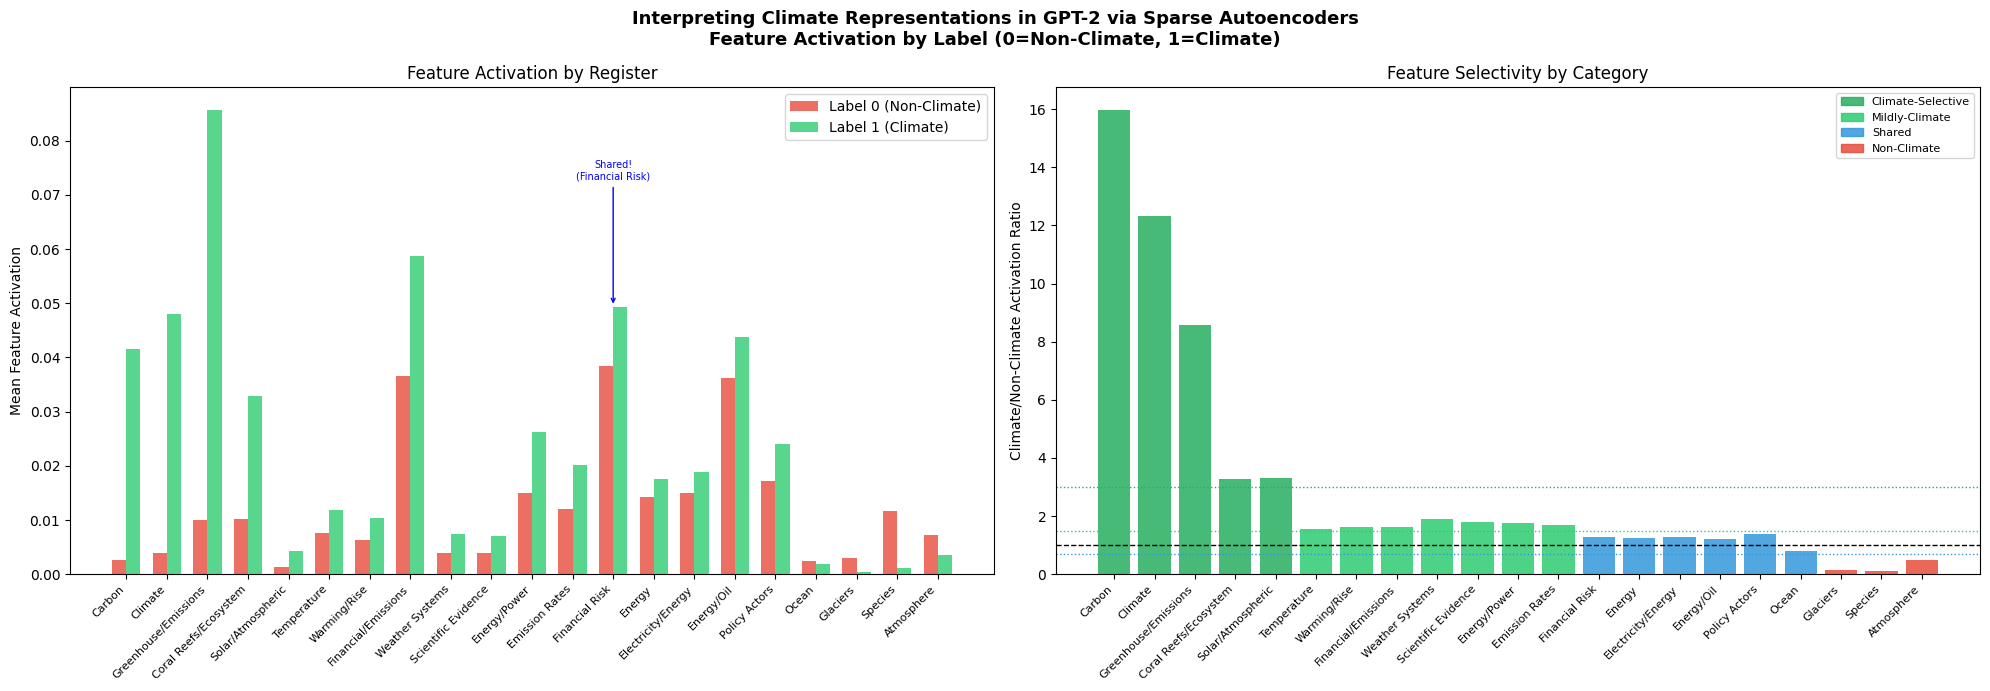

In [55]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle(
    "Interpreting Climate Representations in GPT-2 via Sparse Autoencoders\n"
    "Feature Activation by Label (0=Non-Climate, 1=Climate)",
    fontsize=13, fontweight="bold"
)

x = np.arange(len(df))
width = 0.35
names = df["feature_name"].tolist()

# Plot 1: mean activation per label
ax = axes[0]
ax.bar(x - width/2, df["label0_mean_act"], width, label="Label 0 (Non-Climate)", color="#e74c3c", alpha=0.8)
ax.bar(x + width/2, df["label1_mean_act"], width, label="Label 1 (Climate)", color="#2ecc71", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Mean Feature Activation")
ax.set_title("Feature Activation by Register")
ax.legend()

# annotate shared feature dynamically
shared_row  = df[df["dominant_label"] == "Shared"].iloc[0]
shared_pos  = df[df["feature_idx"] == shared_row["feature_idx"]].index[0]
shared_val  = shared_row["label1_mean_act"]
max_val     = df[["label0_mean_act", "label1_mean_act"]].max().max()

ax.annotate(f"Shared!\n({shared_row['feature_name']})",
    xy=(shared_pos, shared_val),
    xytext=(shared_pos, max_val * 0.85),
    fontsize=7, color="blue",
    arrowprops=dict(arrowstyle="->", color="blue"),
    ha="center"
)

# Plot 2: Selectivity ratio colored by category
ax2 = axes[1]
colors = [COLOR_MAP_LABEL[l] for l in df["dominant_label"]]
ax2.bar(names, df["selectivity_ratio"], color=colors, alpha=0.85)

ax2.axhline(y=1,   color="black",  linestyle="--", linewidth=1, label="Equal activation (ratio=1)")

ax2.axhline(y=3,   color="#27ae60", linestyle=":",  linewidth=1, label="Climate-Selective threshold (3x)")

ax2.axhline(y=1.5, color="#2ecc71", linestyle=":",  linewidth=1, label="Mildly-Climate threshold (1.5x)")

ax2.axhline(y=0.7, color="#3498db", linestyle=":",  linewidth=1, label="Shared threshold (0.7x)")

ax2.set_xticks(range(len(names)))
ax2.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("Climate/Non-Climate Activation Ratio")
ax2.set_title("Feature Selectivity by Category")
ax2.legend(fontsize=7, loc="upper right")

# legend for categories
patches = [mpatches.Patch(color=c, label=l, alpha=0.85)
           for l, c in COLOR_MAP_LABEL.items()]

ax2.legend(handles=patches, fontsize=8, loc="upper right")

plt.tight_layout()

plt.savefig(f"{SAVE_DIR}/feature_analysis_4cat.png", dpi=150, bbox_inches="tight")

plt.show()

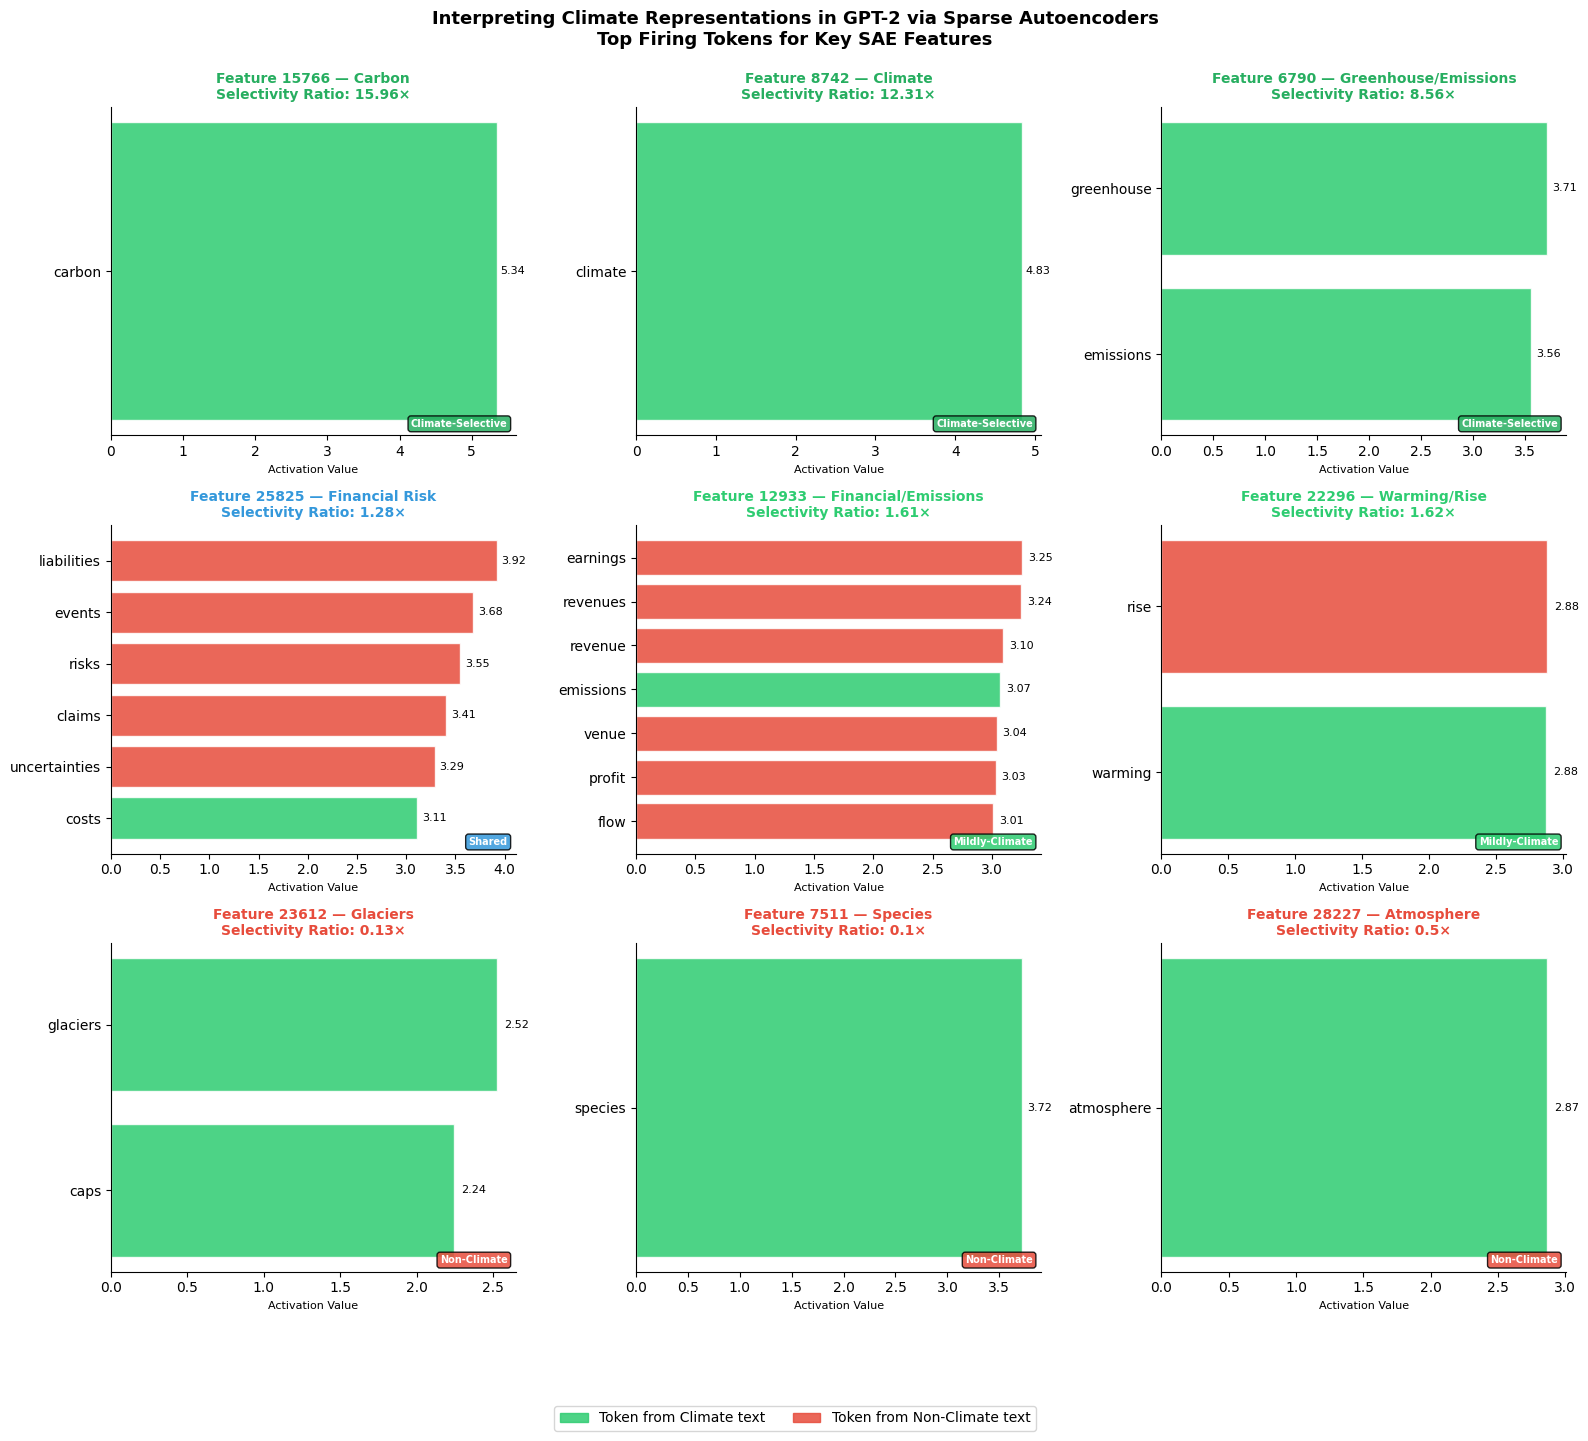

In [56]:
# Top 9 most interesting features for report
highlight_features = [
    15766,  # Carbon (strongest climate-selective)
    8742,   # Climate (core climate)
    6790,   # Greenhouse/Emissions (key climate)
    25825,  # Financial Risk (shared - key finding!)
    12933,  # Financial/Emissions (shared - key finding!)
    22296,  # Warming/Rise (mildly climate)
    23612,  # Glaciers (surprising non-climate!)
    7511,   # Species (surprising non-climate!)
    28227   # Atmosphere (surprising non-climate!)
]

highlight_names = {
    15766: "Carbon",
    8742:  "Climate",
    6790:  "Greenhouse/Emissions",
    25825: "Financial Risk",
    12933: "Financial/Emissions",
    22296: "Warming/Rise",
    23612: "Glaciers",
    7511:  "Species",
    28227: "Atmosphere"
}

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle(
    "Interpreting Climate Representations in GPT-2 via Sparse Autoencoders\n"
    "Top Firing Tokens for Key SAE Features\n",
    fontsize=13, fontweight="bold"
)
axes = axes.flatten()

for plot_idx, feat_idx in enumerate(highlight_features):
    ax        = axes[plot_idx]
    feat_data = df_tokens[df_tokens["feature_idx"] == feat_idx]
    feat_name = highlight_names[feat_idx]
    category  = df[df["feature_idx"] == feat_idx]["dominant_label"].values[0]
    ratio     = df[df["feature_idx"] == feat_idx]["selectivity_ratio"].values[0]
    cat_color = COLOR_MAP_LABEL[category]

    tokens = feat_data["token"].tolist()
    values = feat_data["value"].tolist()
    labels = feat_data["label_name"].tolist()

    token_colors = ["#2ecc71" if l == "Climate" else "#e74c3c" for l in labels]

    bars = ax.barh(range(len(tokens)), values,  color=token_colors, alpha=0.85, edgecolor="white")

    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("Activation Value", fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # title with feature name and ratio
    ax.set_title(
        f"Feature {feat_idx} — {feat_name}\n"
        f"Selectivity Ratio: {ratio}×",
        fontsize=10, fontweight="bold", color=cat_color
    )

    # category badge in corner
    ax.text(0.98, 0.02, category,
            transform=ax.transAxes,
            fontsize=7, color="white",
            ha="right", va="bottom",
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor=cat_color, alpha=0.85))

    # value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", fontsize=8)

# legend
climate_patch    = mpatches.Patch(color="#2ecc71", alpha=0.85, label="Token from Climate text")
nonclimate_patch = mpatches.Patch(color="#e74c3c", alpha=0.85, label="Token from Non-Climate text")

fig.legend(handles=[climate_patch, nonclimate_patch],
           loc="lower center", fontsize=10,
           bbox_to_anchor=(0.5, -0.04),
           ncol=2)

plt.tight_layout(rect=[0, 0.04, 1, 1])

plt.savefig(f"{SAVE_DIR}/top_tokens_highlight_9.png", dpi=150, bbox_inches="tight", pad_inches=0.3)

plt.show()

/tmp/ipykernel_581/3405978042.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(order, rotation=15, ha="right")


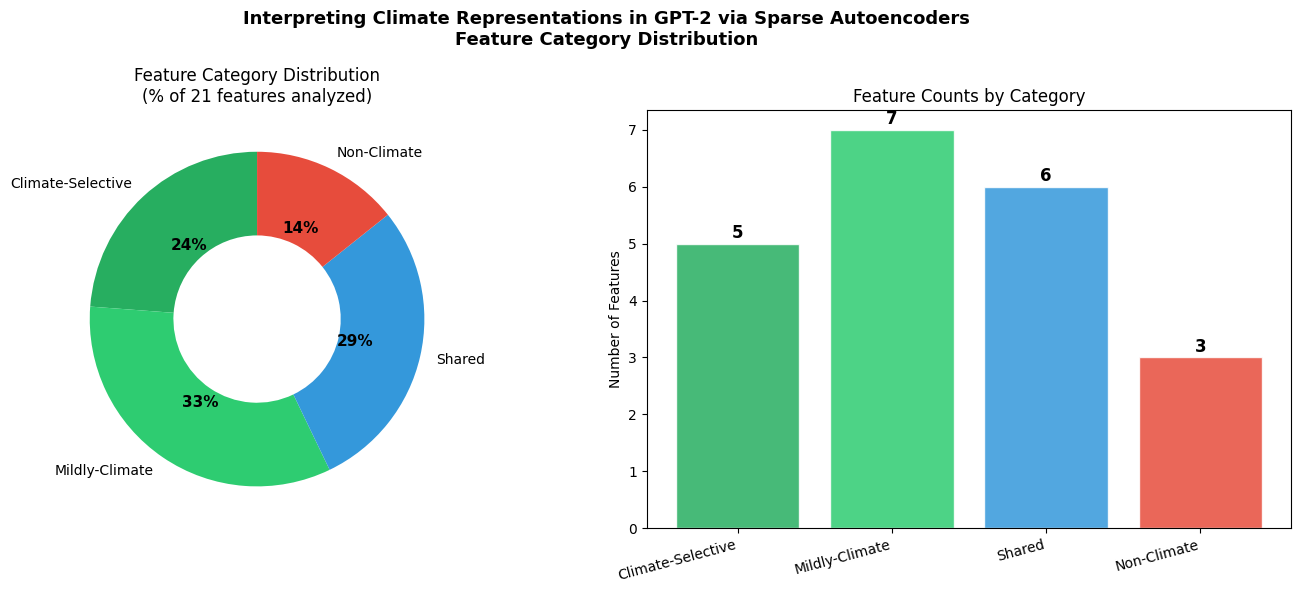

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Interpreting Climate Representations in GPT-2 via Sparse Autoencoders\n"
    "Feature Category Distribution",
    fontsize=13, fontweight="bold"
)

counts = df["dominant_label"].value_counts()
order  = ["Climate-Selective", "Mildly-Climate", "Shared", "Non-Climate"]
counts = counts.reindex(order)
colors = [COLOR_MAP_LABEL[l] for l in order]

# donut chart
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    counts,
    labels=order,
    colors=colors,
    autopct="%1.0f%%",
    startangle=90,
    wedgeprops=dict(width=0.5),   # donut!
    textprops=dict(fontsize=10)
)

for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")

ax.set_title("Feature Category Distribution\n(% of 21 features analyzed)")

# bar chart of counts
ax2 = axes[1]

bars = ax2.bar(order, counts, color=colors, alpha=0.85, edgecolor="white")

ax2.set_ylabel("Number of Features")

ax2.set_title("Feature Counts by Category")

ax2.set_xticklabels(order, rotation=15, ha="right")

for bar, count in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             str(count),
             ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()

plt.savefig(f"{SAVE_DIR}/category_distribution.png", dpi=150, bbox_inches="tight")

plt.show()

***Note on Feature Index Reproducibility: SAE feature indices are not deterministic across training runs. If the SAE is retrained from scratch, feature indices will change and the keyword discovery step must be rerun to identify the new indices. The hardcoded indices in the analysis code are specific to this training run.***